<a href="https://colab.research.google.com/github/Aarjav8055/ML-LAB/blob/main/ML_lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

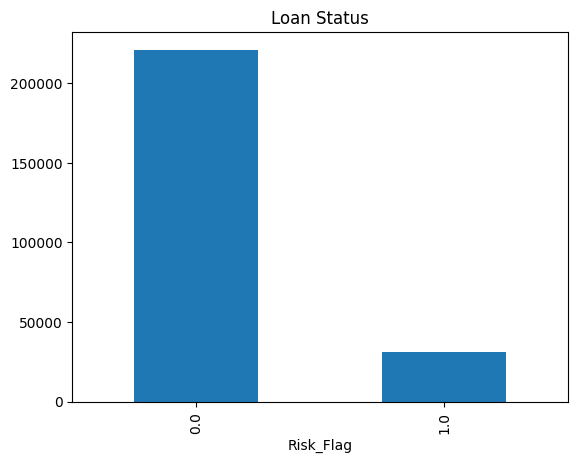

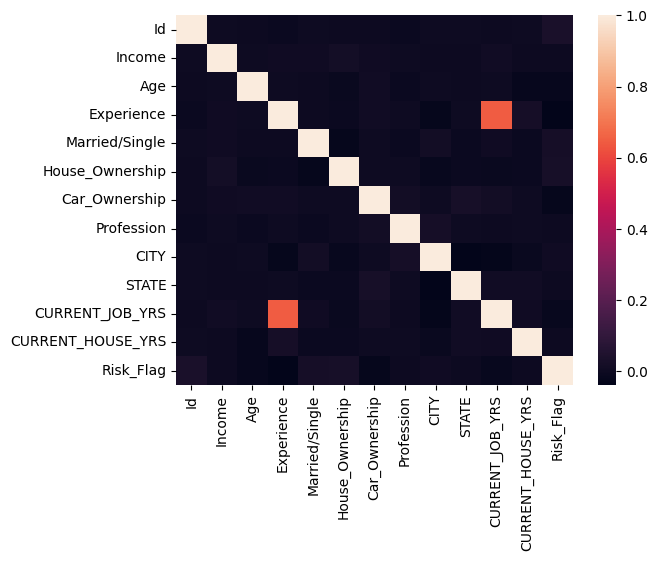

Accuracy: 0.877


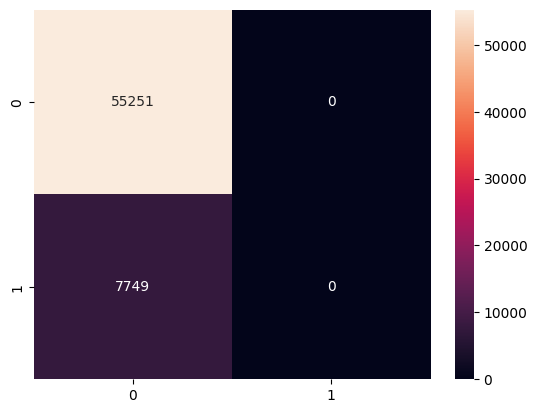

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

df = pd.read_csv("/content/Loan Prediction.csv")
df.columns = df.columns.str.strip()

target = "Loan_Status" if "Loan_Status" in df.columns else df.columns[-1]

df.drop(columns=["Loan_ID"], errors='ignore', inplace=True)


df[df.select_dtypes('number').columns] = SimpleImputer(strategy='mean').fit_transform(df.select_dtypes('number'))
df[df.select_dtypes('object').columns] = SimpleImputer(strategy='most_frequent').fit_transform(df.select_dtypes('object'))

for col in df.select_dtypes('object'):
    df[col] = LabelEncoder().fit_transform(df[col])

# Visualization
df[target].value_counts().plot(kind='bar', title="Loan Status")
plt.show()

sns.heatmap(df.corr())
plt.show()

X = df.drop(target, axis=1)
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)

X_train = StandardScaler().fit_transform(X_train)
X_test = StandardScaler().fit_transform(X_test)

model = LogisticRegression(max_iter=500).fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')
plt.show()